# Машинное обучение. ВМК МГУ

# Практическое задание 3: Линейные модели: регрессия

## Уровень: **Исследовательский (Research)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

Цель данного задания:

- Узнать, что такое переобучение и как с ним бороться в линейных моделях;
- Понять, чем отличаются разные регуляризаторы;
- Научиться решать задачу регрессии линейными моделями.

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: 7 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.23MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")
%matplotlib inline

## Линейная регрессия и регуляризация

Напомним, что линейная регрессия — это модель следующего вида: a ( x ) = ⟨ w , x ⟩ + b a ( x ) = ⟨ w , x ⟩ + b где w ∈ R d w ∈ R d , b ∈ R b ∈ R . Обучить линейную регрессию — значит найти w w и b b .

В модели линейной регрессии с l 2 l 2 регуляризацией мы оптимизируем следующий функционал:

1 N ⋅ ∑ M i = 1 ( w 1 ⋅ x i 1 + … w n ⋅ x i n + b − y i ) 2 + α 2 ⋅ ( w 2 1 + ⋯ + w 2 n ) → min w 1 , … , w n , b 1 N ⋅ ∑ i = 1 M ( w 1 ⋅ x i 1 + … w n ⋅ x i n + b − y i ) 2 + α 2 ⋅ ( w 1 2 + ⋯ + w n 2 ) → min w 1 , … , w n , b

В модели линейной регрессии с l 1 l 1 регуляризацией мы оптимизируем следующий функционал:

1 N ⋅ ∑ M i = 1 ( w 1 ⋅ x i 1 + … w n ⋅ x i n + b − y i ) 2 + α ⋅ ( | w 1 | + ⋯ + | w n | ) → min w 1 , … , w n , b 1 N ⋅ ∑ i = 1 M ( w 1 ⋅ x i 1 + … w n ⋅ x i n + b − y i ) 2 + α ⋅ ( | w 1 | + ⋯ + | w n | ) → min w 1 , … , w n , b

### **Задание 1 [1 балл]**

Почему при обучении линейных моделей, коэффициент b b не регуляризуется? Дайте ответ с опорой на лекции. Возможно вам также поможет картика из базовой части

**Значение b не зависит от весов каких-то
признаков, это просто числовой сдвиг, чтобы обеспечить правильность
отклика. Его регуляризация была бы бессмысленной, так как она бы никак
не предотвратила переобучение, а наоборот сдвинула бы отклик в другую
сторону, тем самым породила бы смещение прогноза и неправильные
результаты**

Рассмотрим модель линейной регрессии с l 2 l 2
регуляризацией. В sklearn эта модель реализована посредством класса
Ridge. В нём есть методы fit и predict. Первый принимает на вход
обучающую выборку и вектор целевых переменных и обучает модель, второй,
будучи вызванным после обучения модели, возвращает предсказание на
выборке.

Сгенерируем случайные данные. Пусть x x будет обычным числом из равномерного распределения, а y = 0.5 ⋅ x + 0.1 𝑦 = 0.5 ⋅ x + 0.1 — целевая переменная. При этом наблюдаем мы ¯ ¯ ¯ y = y + ε , ε ∼ N ( 0 , 0.01 ) y ¯ = y + ε , ε ∼ N ( 0 , 0.01 ) . Добавим в данные к переменной x x её же умноженную на 3 3 . То есть, теперь у нас два признака x 1 x 1 и x 2 = 3 ⋅ x 1 x 2 = 3 ⋅ x 1 .

Поскольку y = c ⋅ 0.5 ⋅ x 1 + 1 − c 6 ⋅ x 2 + 0.1 y = c ⋅ 0.5 ⋅ x 1 + 1 − c 6 ⋅ x 2 + 0.1 , где c c
любое сколь угодно большое вещественное число. То, как мы могли
убедиться в базовой части, без регуляризации есть риск выучить очень
большие веса.

Посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
np.random.seed(1)
X = np.random.uniform(0, 1, 100)
Y = X * 0.5 + 0.1 + np.random.randn(100) * 0.1

X3 = np.hstack((X[:, None], 3 * X[:, None]))
Y3 = X3[:, 0] * 0.5 + 0.1 + np.random.randn(100) * 0.1

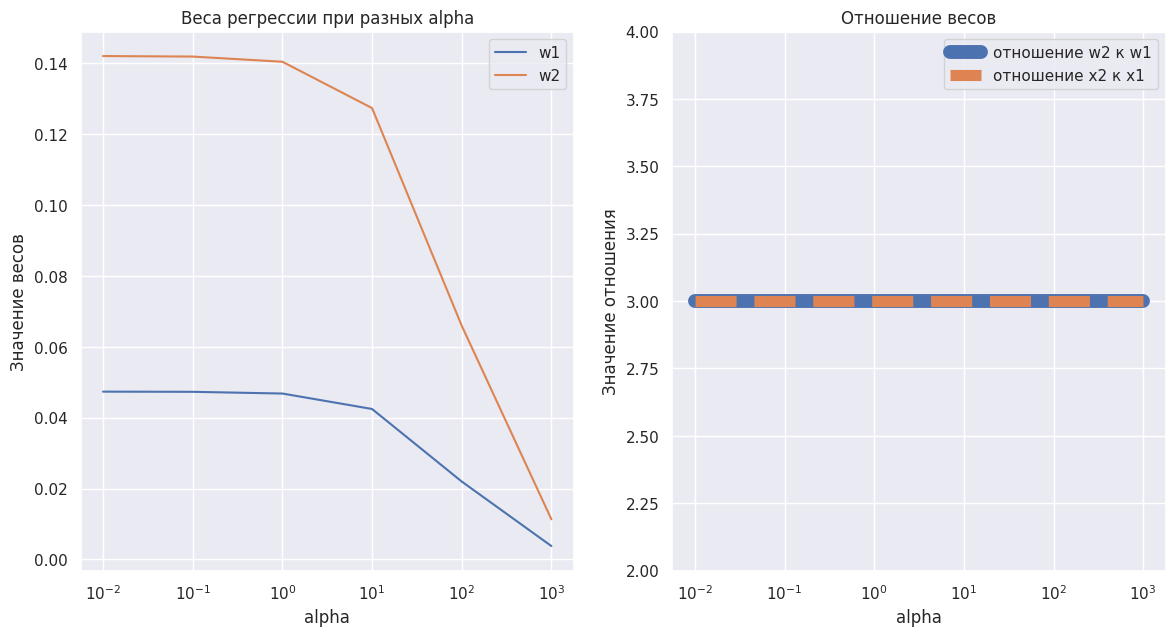

In [ ]:
w1 = []
w2 = []

alphas = [0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    reg = Ridge(alpha=alpha)
    reg.fit(X3, Y3)
    w1.append(reg.coef_[0])
    w2.append(reg.coef_[1])

w1 = np.array(w1)
w2 = np.array(w2)

fig, axs = plt.subplots(figsize=(14, 7), ncols=2)
axs[0].plot(alphas, w1, label="w1")
axs[0].plot(alphas, w2, label="w2")
axs[0].set_xscale("log")
axs[0].set_title("Веса регрессии при разных alpha")
axs[0].set_xlabel("alpha")
axs[0].set_ylabel("Значение весов")
axs[0].legend()
axs[1].plot(alphas, w2 / w1, label="отношение w2 к w1", linewidth=10)
axs[1].plot([0.01, 1000], [3, 3], label="отношение x2 к x1", linestyle="--", linewidth=8)
axs[1].set_xscale("log")
axs[1].set_ylim(2,4)
axs[1].set_xlabel("alpha")
axs[1].set_ylabel("Значение отношения")
axs[1].set_title("Отношение весов")
axs[1].legend()
plt.show()

### **Задание 2 [2 баллa]**

Как
думаете, почему отношение между весами постоянно? (подсказка,
необходимо выписать функцию потерь и посчитать производные по весам)

** Функция потерь с регуляризацией L2 выглядит так: J ( w ) = ∑ n i = 1 ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) 2 + α ( w 2 1 + w 2 2 ) J ( w ) = ∑ i = 1 n ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) 2 + α ( w 1 2 + w 2 2 )
∂ J ∂ w 1 = − 2 ∑ n i = 1 x 1 i ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) + 2 α w 1 = − 2 ∑ n i = 1 x 1 i ( y i − ( w 1 x 1 i + 3 w 2 x 1 i ) ) + 2 α w 1 = 0 ∂ J ∂ w 1 = − 2 ∑ i = 1 n x 1 i ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) + 2 α w 1 = − 2 ∑ i = 1 n x 1 i ( y i − ( w 1 x 1 i + 3 w 2 x 1 i ) ) + 2 α w 1 = 0
∂ J ∂ w 2 = − 2 ∑ n i = 1 x 2 i ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) + 2 α w 2 = − 2 ∑ n i = 1 3 x 1 i ( y i − ( w 1 x 1 i + 3 w 2 x 1 i ) ) + 2 α w 2 = 0 ∂ J ∂ w 2 = − 2 ∑ i = 1 n x 2 i ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) + 2 α w 2 = − 2 ∑ i = 1 n 3 x 1 i ( y i − ( w 1 x 1 i + 3 w 2 x 1 i ) ) + 2 α w 2 = 0

Признаки ЛНЗ, следовательно w 2 / w 1 w 2 / w 1 const. Отношение весов стремится к отношению коэффициентов при признаках, которое остаётся постоянным при изменении α α .
</font>

Заметим, что при l 2 l 2
регуляризации в данном примере веса получились пропорциональны
значениям признаков. При этом, мы знаем, что оба признака взаимно
однозначны, и прогноз можно делать только по одному из них. Для этого
придумана l 1 l 1 регуляризация. В билиотеке sklearn линейная регрессия с l 1 l 1 регуляризацией реализована в классе Lasso

### **Задание 3 [2 баллa]**

Почему в нашем примере l 1 l 1
регуляризация приведёт к разреживанию весов? (подсказка, нужно опять
подсчитать производную, но обратите внимание на дифференцируемость
модуля).

** J ( w ) = ∑ n i = 1 ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) 2 + α ( | w 1 | + | w 2 | ) J ( w ) = ∑ i = 1 n ( y i − ( w 1 x 1 i + w 2 x 2 i ) ) 2 + α ( | w 1 | + | w 2 | )
Когда мы считаем градиент, производная модуля веса оказывается либо -1
(если вес отрицательный), либо 1 (если положительный). В нуле
производной нет, но это как раз хорошо — во время оптимизации веса легко
скатываются к нулю, если их вклад в результат меньше α α .

Если в данных есть зависимые признаки, например x 2 = 2 ⋅ x 1 x 2 = 2 ⋅ x 1 , то L1-регуляризация часто оставляет один из них (скажем, w 1 w 1 ) с ненулевым весом, а второй ( w 2 w 2 ) делает равным нулю. Это удобно, потому что позволяет модели автоматически выбирать самые важные признаки, убирая лишнее.
**</font>

Добавим l 1 l 1 регуляризацию и посмотрим, как меняется значения весов, в зависимости от значения коэффициента регуляризации.

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
reg = Lasso(alpha=1., max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 1.")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.1, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.1")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.01, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.01")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.0001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.0001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

reg = Lasso(alpha=0.00001, max_iter=1000, tol=1e-4)
reg.fit(X3, Y3)
print("Веса, при alpha = 0.00001")
print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
print()

Веса, при alpha = 1.
w1: 0.0 	w2: 0.0

Веса, при alpha = 0.1
w1: 0.0 	w2: 0.029684463509327023

Веса, при alpha = 0.01
w1: 0.0 	w2: 0.14506160917248503

Веса, при alpha = 0.001
w1: 0.0 	w2: 0.1565993237388008

Веса, при alpha = 0.0001
w1: 0.0 	w2: 0.1577530951954324

Веса, при alpha = 0.00001
w1: 0.3966873199145481 	w2: 0.025639365702912847


### **Задание 4 [2 баллa]**

Почему в итоге при α = 0.00001 α = 0.00001 получились веса не равные нулю?

**Подсказка**

Обратите внимание на то, каким странным получился вес w 2 w 2

** **Ваши выводы тут:**

Когда параметр α α
очень маленький, регуляризация почти не влияет на обучение. Модель
начинает вести себя как обычная линейная регрессия, где главное —
минимизировать ошибку предсказания. При этом штраф за ненулевые веса
становится таким незначительным, что модель просто игнорирует его и
подбирает веса, чтобы как можно лучше подстроиться под данные, даже если
эти веса далеко не нулевые.
Чтобы понять, успела ли модель завершить обучение или остановилась из-за
ограничения на число итераций, можно посмотреть атрибут n iter у модели Lasso. Он показывает, сколько итераций было выполнено.
В случае с α = 0.00001 α = 0.00001
видно, что модель использовала все доступные итерации. Это значит, что
ей не хватило времени (или ресурсов) на полное обучение.**</font>

In [ ]:
alphas = [1., 0.1, 0.01, 0.001, 0.0001, 0.00001]

for alpha in alphas:
    reg = Lasso(alpha=alpha, max_iter=1000, tol=1e-4)
    reg.fit(X3, Y3)
    print(f"Веса при alpha = {alpha}")
    print("w1:", reg.coef_[0], "\tw2:", reg.coef_[1])
    print(f"Прошло итераций: {reg.n_iter_}/{reg.max_iter}")

Веса при alpha = 1.0
w1: 0.0 	w2: 0.0
Прошло итераций: 1/1000
Веса при alpha = 0.1
w1: 0.0 	w2: 0.029684463509327023
Прошло итераций: 2/1000
Веса при alpha = 0.01
w1: 0.0 	w2: 0.14506160917248503
Прошло итераций: 7/1000
Веса при alpha = 0.001
w1: 0.0 	w2: 0.1565993237388008
Прошло итераций: 63/1000
Веса при alpha = 0.0001
w1: 0.0 	w2: 0.1577530951954324
Прошло итераций: 617/1000
Веса при alpha = 1e-05
w1: 0.3966873199145481 	w2: 0.025639365702912847
Прошло итераций: 1000/1000


В предущих блоках мы использовали модельные примеры, в которых y y зависел от x x линейно. Но так бывает далеко не всегда.

### **Задание 5 [1 баллa]**

Придумайте, сгенерируйте и визуализируйте пример, в котором линейная регрессия будет плохо классифицировать данные.

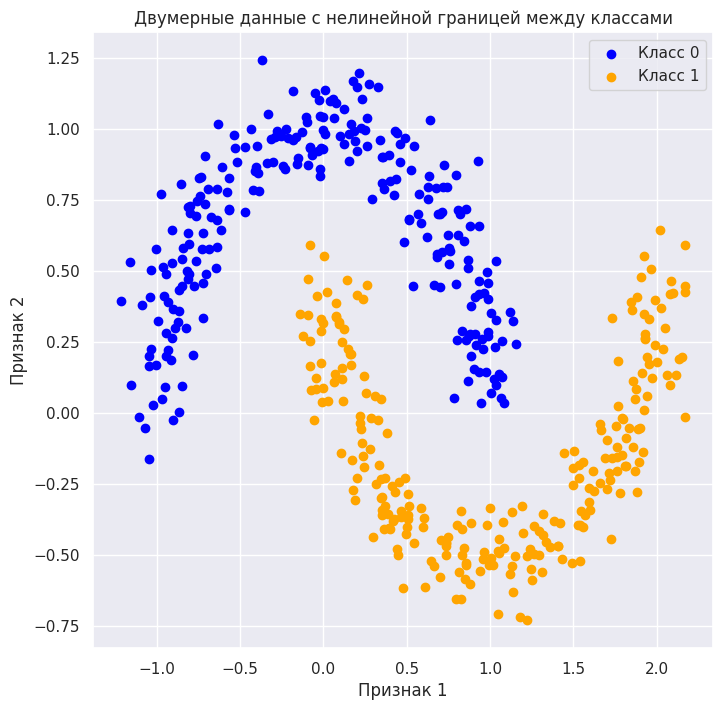

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Класс 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='orange', label='Класс 1')
plt.title('Двумерные данные с нелинейной границей между классами')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True)
plt.show()

### **Задание 6 [2 баллa]**

Приведите искусственный пример (можно даже очень неправдоподобный), когда линейная регрессия с l 2 l 2
регуляризацией гарантированно занулит какой-нибудь признак? Покажите
(теоретически или программно), что признак действительно зануляется

In [ ]:
from sklearn.linear_model import Ridge

X = np.array([[1, 1], [2, 1], [3, 1], [4, 1], [5, 1]])
y = np.array([1, 2, 3, 4, 5])

ridge_model = Ridge(alpha=10)
ridge_model.fit(X, y)

ridge_coefficients = ridge_model.coef_
ridge_coefficients

array([0.5, 0. ])


**x2 -- признак, но совсем неинформативный и бессмысленный -- он всегда 1. Поэтому он будет занулён регуляризацией**

Выводы В первой части задания по линейным моделям мы должны были узнать:
.

1. Зачем нужна регуляризация.
2. Как отбирать значащие признаки.
3. Когда линейные модели работают хорошо, а когда плохо

Во второй части мы будем применять линейные модели
для классификации реальных данных, где мы сможем проверить наши выводы,
полученные на искуственных примерах. А также убедимся в полезности
нормировки и научимся работать с разными видами данных.